In [1]:
from torch.utils.data import Dataset

In [2]:
help(Dataset)

Help on class Dataset in module torch.utils.data.dataset:

class Dataset(typing.Generic)
 |  An abstract class representing a :class:`Dataset`.
 |  
 |  All datasets that represent a map from keys to data samples should subclass
 |  it. All subclasses should overwrite :meth:`__getitem__`, supporting fetching a
 |  data sample for a given key. Subclasses could also optionally overwrite
 |  :meth:`__len__`, which is expected to return the size of the dataset by many
 |  :class:`~torch.utils.data.Sampler` implementations and the default options
 |  of :class:`~torch.utils.data.DataLoader`. Subclasses could also
 |  optionally implement :meth:`__getitems__`, for speedup batched samples
 |  loading. This method accepts list of indices of samples of batch and returns
 |  list of samples.
 |  
 |  .. note::
 |    :class:`~torch.utils.data.DataLoader` by default constructs an index
 |    sampler that yields integral indices.  To make it work with a map-style
 |    dataset with non-integral ind

In [3]:
from torch.utils.data import Dataset
from PIL import Image
import os
from os import path

## 1. 获取当前工作目录

In [4]:
# get data directory (using getcwd() is needed to support running example in generated IPython notebook)
home_path = os.getcwd()
# Read the whole text.
print(home_path)
img_path = path.join(home_path, 'imgs')
print(img_path)

/home/summer/PythonProject/pythonProject5/10_Pytorch
/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs


## 2. 获取图片地址列表

In [5]:
def read_images_from_folder(folder_path):
    """
    遍历指定文件夹下的所有图片文件
    
    :param folder_path: 图片文件夹的路径
    """
    image_extensions = ['.jpg', '.jpeg', '.png', '.gif', '.bmp']  # 常见图片文件扩展名列表，可以根据需要添加
    images = []

    for filename in os.listdir(folder_path):
        # 检查文件是否为图片（通过扩展名判断）
        if any(filename.lower().endswith(ext) for ext in image_extensions):
            img_path = os.path.join(folder_path, filename)
            # 这里可以对图片进行操作，例如打开、显示或保存其信息
            # 例如，如果要打开图片，可以这样做：
            # with Image.open(img_path) as img:
            #     img.show()  # 显示图片
            images.append(img_path)  # 将图片路径添加到列表中，或根据需要存储其他信息

    return images

# 使用函数获取图片地址的列表
images = read_images_from_folder(img_path) 
print(f"找到了{len(images)}张图片。")
print(images)

找到了9张图片。
['/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/airplane.png', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/003.jpg', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/dog.png', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/005.png', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/000.jpg', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/002.jpg', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/001.png', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/004.png', '/home/summer/PythonProject/pythonProject5/10_Pytorch/imgs/006.png']


(478, 354)


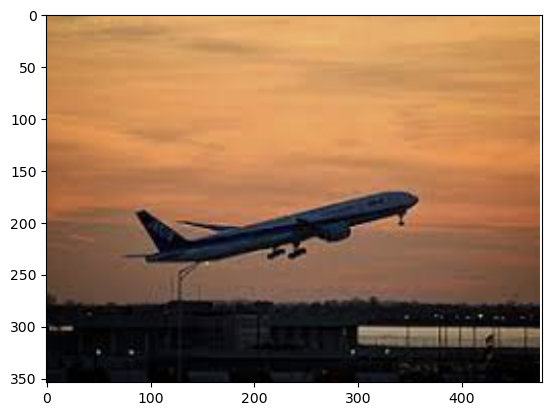

In [6]:
img = Image.open(images[0])
print(img.size) # 显示图像大小
# img.show() # 显示图片 ,但这里会使用默认的软件打开
import matplotlib.pyplot as plt
plt.imshow(img)

In [7]:
class MyData(Dataset):
    def __init__(self, root_dir, label_dir):
        self.root_dir = root_dir
        self.label_dir = label_dir
        self.path = os.path.join(self.root_dir, self.label_dir)
        self.img_path = os.listdir(self.path)

    def __getitem__(self, index):
        img_name = self.img_path[index]
        img_item = os.path.join(self.root_dir, self.label_dir, img_name)
        image = Image.open(img_item)
        label = self.label_dir
        return image, label
    
    def __len__(self):
        return len(self.img_path)

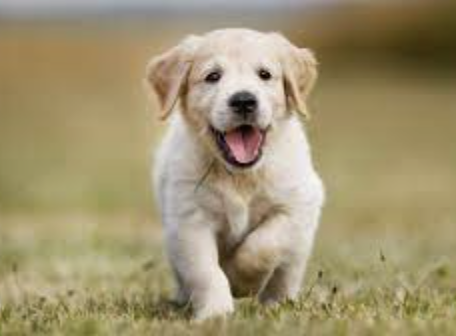

In [8]:
root_dir = os.getcwd()
ants_label_dir = "imgs"
ants_dataset = MyData(root_dir, ants_label_dir)
img, label = ants_dataset[2]
img